# **1. Perkenalan Dataset**


**Business Understanding**

1. memahami perilaku customer,
2. mengidentifikasi customer loyal,
3. menemukan high spender,
4. mengetahui inactive customer.

# **2. Import Library**

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer
import joblib

# **3. Data Wrangling**

## Data loading

In [5]:
# Upload ke Google Colab
from google.colab import files
uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [6]:
# Simpan ke Folder Kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [7]:
# Download Dataset
!kaggle datasets download -d vijayuv/onlineretail
# Extract ZIP
!unzip onlineretail.zip

Dataset URL: https://www.kaggle.com/datasets/vijayuv/onlineretail
License(s): CC0-1.0
100% 7.20M/7.20M [00:00<00:00, 52.2MB/s]

Archive:  onlineretail.zip
  inflating: OnlineRetail.csv        


In [1]:
# Load Dataset
import pandas as pd

df = pd.read_csv(
    'OnlineRetail.csv',
    encoding='ISO-8859-1'
)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## Data assesing

In [2]:
# cek info data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [3]:
# cek missing value
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [4]:
#  cek duplikasi data
print('Duplilasi data ada: ', df.duplicated().sum())

Duplilasi data ada:  5268


In [5]:
# Lihat Contoh Data Duplikat
df[df.duplicated()].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,12/1/2010 11:49,2.95,17920.0,United Kingdom


In [6]:
# cek analisa deskriptif
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


## Data Cleaning

In [7]:
# Hapus missing value
df = df.dropna(subset=['CustomerID', 'Description'])

# Hapus duplikasi
df = df.drop_duplicates()

# Convert tipe data
df['CustomerID'] = df['CustomerID'].astype('int')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Hapus quantity negatif (return/cancel)
df = df[df['Quantity'] > 0]

# Hapus harga <= 0
df = df[df['UnitPrice'] > 0]

# lihat hasil akhir
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  int64         
 7   Country      392692 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 27.0+ MB


**Insight**

Pada tahap data preprocessing dilakukan pengecekan data duplikat menggunakan fungsi duplicated(). Hasil pengecekan menunjukkan terdapat sebanyak 5.268 data duplikat pada dataset transaksi.

Data duplikat merupakan baris data yang memiliki seluruh nilai atribut yang sama, meliputi InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, dan Country. Keberadaan data duplikat dapat menyebabkan hasil analisis menjadi kurang akurat karena transaksi yang sama tercatat lebih dari satu kali.

Jika data duplikat tidak ditangani, maka dapat memengaruhi hasil perhitungan pada analisis, seperti:

nilai total pembelian (Monetary) menjadi lebih besar dari kondisi sebenarnya,
frekuensi transaksi (Frequency) meningkat secara tidak valid,
hasil segmentasi pelanggan dan clustering menjadi bias.

Oleh karena itu, data duplikat dihapus menggunakan metode drop_duplicates() agar setiap transaksi hanya tercatat satu kali dan kualitas data menjadi lebih baik untuk proses analisis selanjutnya.

# **4. Exploratory Data Analysis (EDA)**


In [14]:
# Copy data
df_clean = df.copy()
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


/tmp/ipykernel_46460/4156201998.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


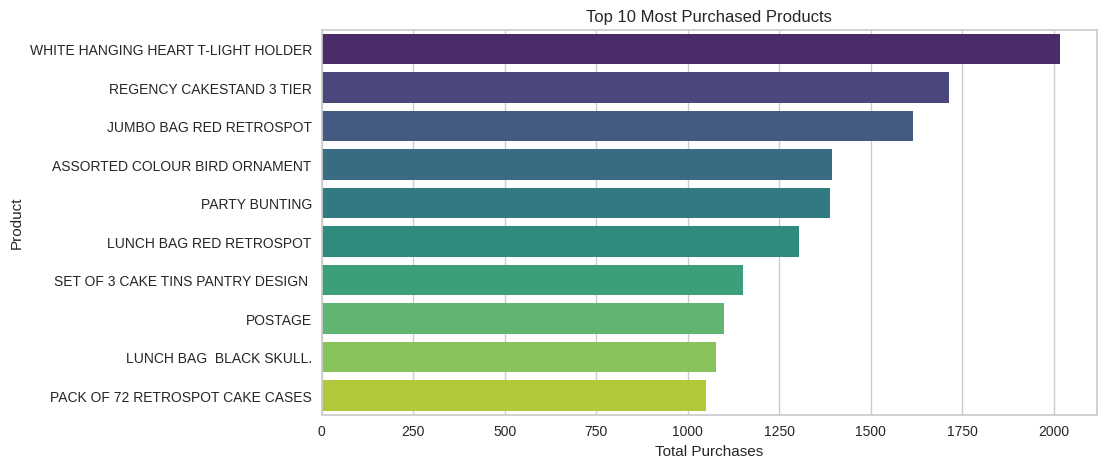

In [15]:
# Produk paling sering dibeli
# Top 10 product
top_product = df_clean['Description'].value_counts().head(10)

# Visualisasi
plt.figure(figsize=(10,5))

sns.barplot(
    x=top_product.values,
    y=top_product.index,
    palette='viridis'
)

plt.title('Top 10 Most Purchased Products')
plt.xlabel('Total Purchases')
plt.ylabel('Product')
plt.show()

/tmp/ipykernel_46460/469980451.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


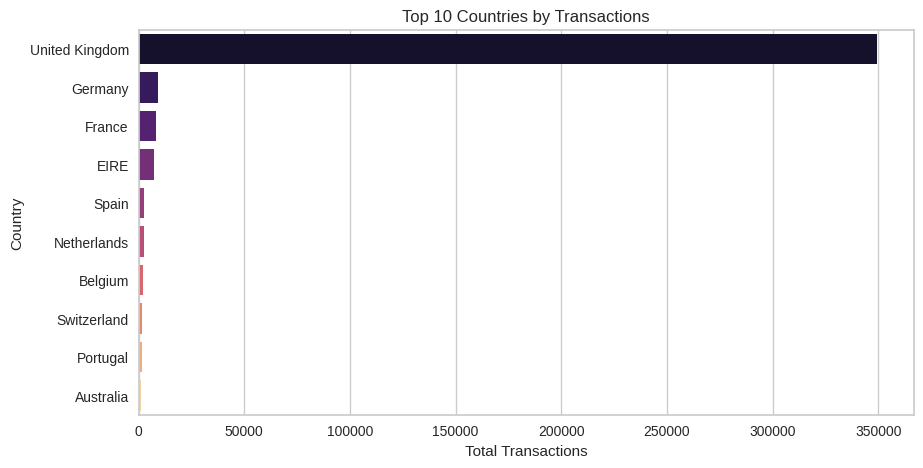

In [16]:
# Top Country Negara dengan transaksi terbanyak
# Top country
top_country = df_clean['Country'].value_counts().head(10)

# Visualisasi
plt.figure(figsize=(10,5))

sns.barplot(
    x=top_country.values,
    y=top_country.index,
    palette='magma'
)

plt.title('Top 10 Countries by Transactions')
plt.xlabel('Total Transactions')
plt.ylabel('Country')
plt.show()

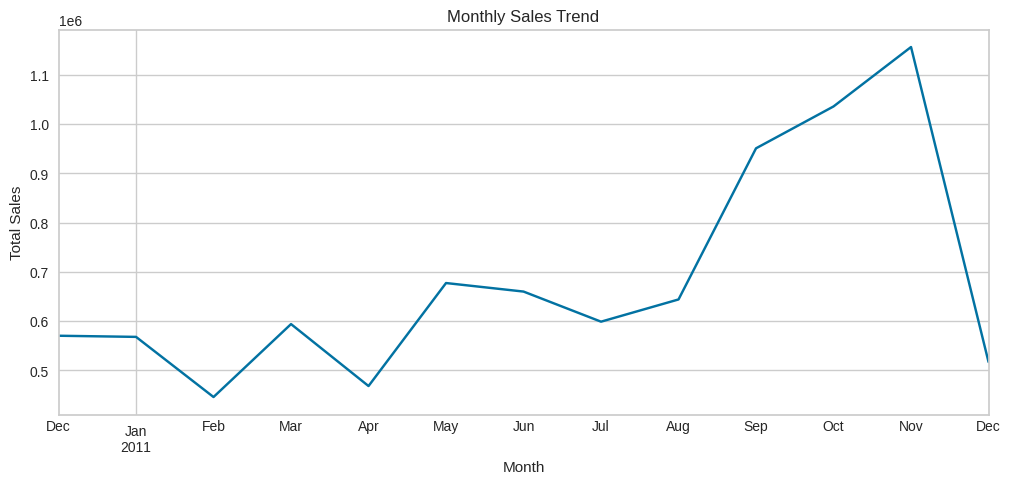

In [17]:
# Tren penjualan per bulan
# Konversi InvoiceDate ke datetime
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# Membuat kolom total sales
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Membuat kolom bulan
df_clean['Month'] = df_clean['InvoiceDate'].dt.to_period('M')

# Monthly sales
monthly_sales = df_clean.groupby('Month')['TotalPrice'].sum()

# Visualisasi
plt.figure(figsize=(12,5))

monthly_sales.plot()

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

/tmp/ipykernel_46460/3927575546.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


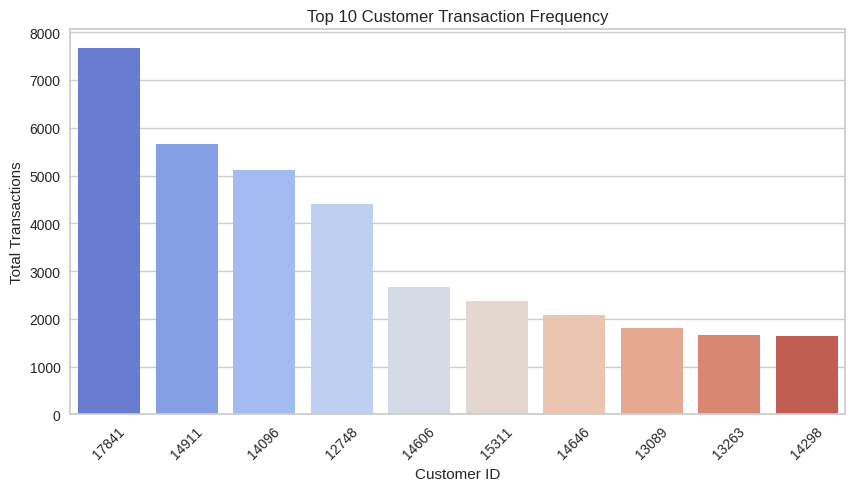

In [18]:
# Customer dengan transaksi terbanyak
# Frekuensi customer
customer_freq = df_clean['CustomerID'].value_counts().head(10)

# Visualisasi
plt.figure(figsize=(10,5))

sns.barplot(
    x=customer_freq.index.astype(str),
    y=customer_freq.values,
    palette='coolwarm'
)

plt.title('Top 10 Customer Transaction Frequency')
plt.xlabel('Customer ID')
plt.ylabel('Total Transactions')
plt.xticks(rotation=45)
plt.show()

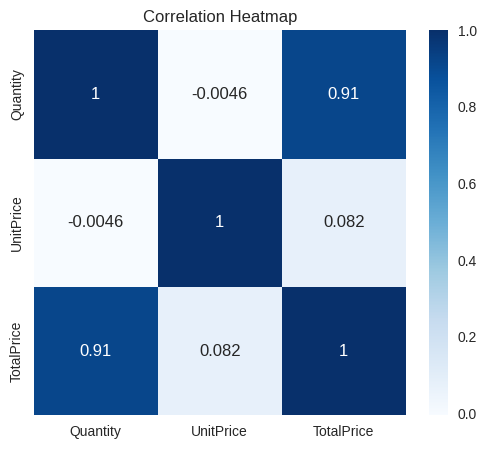

In [19]:
# Heatmap Korelasi
# Korelasi numerik
corr = df_clean[
    [
        'Quantity',
        'UnitPrice',
        'TotalPrice'
    ]
].corr()

# Visualisasi heatmap
plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap='Blues'
)

plt.title('Correlation Heatmap')
plt.show()

# **5. Data Preprocessing**

## Feature Engineering (RFM)

In [20]:
# copy data
df_clean_prep = df_clean.copy()
df_clean_prep.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  int64         
 7   Country      392692 non-null  object        
 8   TotalPrice   392692 non-null  float64       
 9   Month        392692 non-null  period[M]     
dtypes: datetime64[ns](1), float64(2), int64(2), object(4), period[M](1)
memory usage: 33.0+ MB


In [21]:
# Membuat Total Price Karena dataset biasanya belum punya total transaksi.

df_clean_prep['TotalPrice'] = df_clean_prep['Quantity'] * df_clean_prep['UnitPrice']
df_clean_prep.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12


In [22]:
# Menentukan Tanggal AcuanBiasanya menggunakan tanggal transaksi terakhir + 1 hari
snapshot_date = df_clean_prep['InvoiceDate'].max() + pd.Timedelta(days=1)

print(snapshot_date)

2011-12-10 12:50:00


In [23]:
# Membuat RFM Table
rfm = df_clean_prep.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

In [24]:
# Rename Kolom
rfm.columns = [
    'Recency',
    'Frequency',
    'Monetary'
]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


**Insight**

RFM merupakan metode analisis perilaku pelanggan yang digunakan untuk memahami karakteristik customer berdasarkan aktivitas transaksi. RFM terdiri dari tiga komponen utama yaitu Recency, Frequency, dan Monetary. Recency menunjukkan seberapa lama sejak pelanggan terakhir melakukan transaksi, Frequency menunjukkan seberapa sering pelanggan melakukan transaksi, sedangkan Monetary menunjukkan total nilai pengeluaran pelanggan. Metode ini banyak digunakan pada bidang retail, e-commerce, dan customer analytics karena mampu merepresentasikan perilaku serta nilai pelanggan secara lebih ringkas dan informatif.

Pada dataset Online Retail, penggunaan RFM dilakukan karena data yang dimiliki berupa data transaksi pelanggan yang mencakup informasi waktu transaksi, jumlah pembelian, dan nilai transaksi. Dengan menggunakan RFM, data transaksi mentah dapat diubah menjadi profil perilaku pelanggan sehingga proses clustering menjadi lebih relevan dan bermakna. Hasil clustering nantinya dapat digunakan untuk mengidentifikasi kelompok pelanggan seperti loyal customer, high spender, maupun inactive customer.

RFM tidak selalu digunakan pada setiap project clustering. Penggunaan metode ini bergantung pada tujuan analisis dan jenis dataset yang digunakan. Jika project clustering berfokus pada segmentasi pelanggan berdasarkan perilaku transaksi dan nilai pelanggan, maka RFM sangat direkomendasikan. Namun, pada project lain seperti analisis fraud, clustering film Netflix, atau clustering citra, RFM biasanya tidak digunakan karena tujuan analisis bukan untuk memahami perilaku transaksi pelanggan. Oleh karena itu, pemilihan penggunaan RFM harus disesuaikan dengan konteks bisnis dan karakteristik data yang digunakan.


### Visualisasi Distribusi RFM

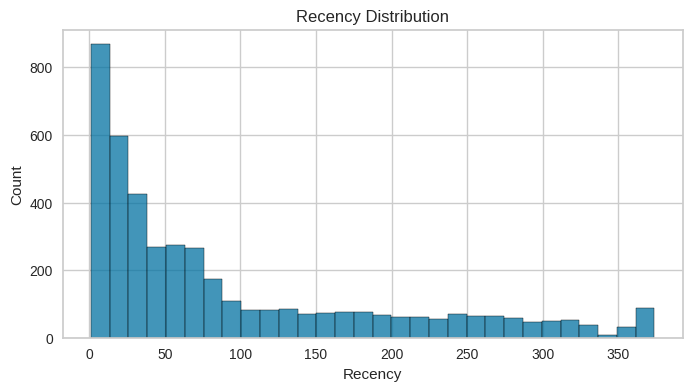

In [25]:
# Recency
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))

sns.histplot(rfm['Recency'], bins=30)

plt.title('Recency Distribution')
plt.show()

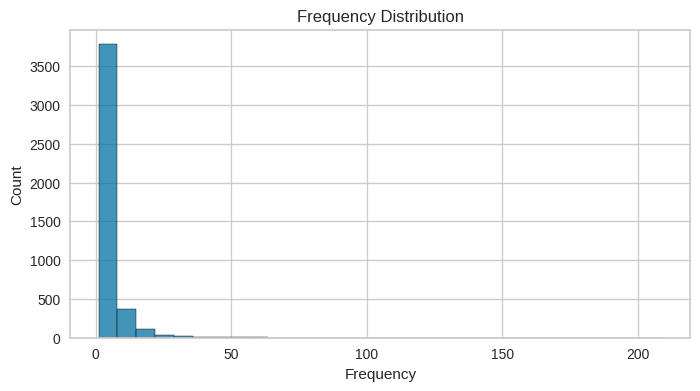

In [26]:
# Frequency
plt.figure(figsize=(8,4))

sns.histplot(rfm['Frequency'], bins=30)

plt.title('Frequency Distribution')
plt.show()

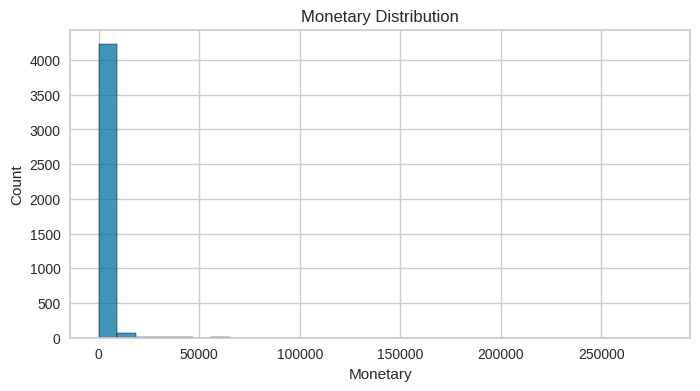

In [27]:
# Monetary
plt.figure(figsize=(8,4))

sns.histplot(rfm['Monetary'], bins=30)

plt.title('Monetary Distribution')
plt.show()

## Outlier Handling

In [28]:
# cek outlier

numeric_columns = rfm.select_dtypes(include=['number']).columns

outlier_summary = []

for col in numeric_columns:
    Q1 = rfm[col].quantile(0.25)
    Q3 = rfm[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = rfm[(rfm[col] < lower_bound) | (rfm[col] > upper_bound)]

    outlier_summary.append({
        'Feature': col,
        'Jumlah Outlier': len(outliers),
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound
    })

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df)

     Feature  Jumlah Outlier  Lower Bound  Upper Bound
0    Recency             155      -168.00       328.00
1  Frequency             285        -5.00        11.00
2   Monetary             425     -1724.69      3691.77


In [29]:
# handling outlier dengan Log Transformation
import numpy as np

rfm['Recency'] = np.log1p(rfm['Recency'])
rfm['Frequency'] = np.log1p(rfm['Frequency'])
rfm['Monetary'] = np.log1p(rfm['Monetary'])

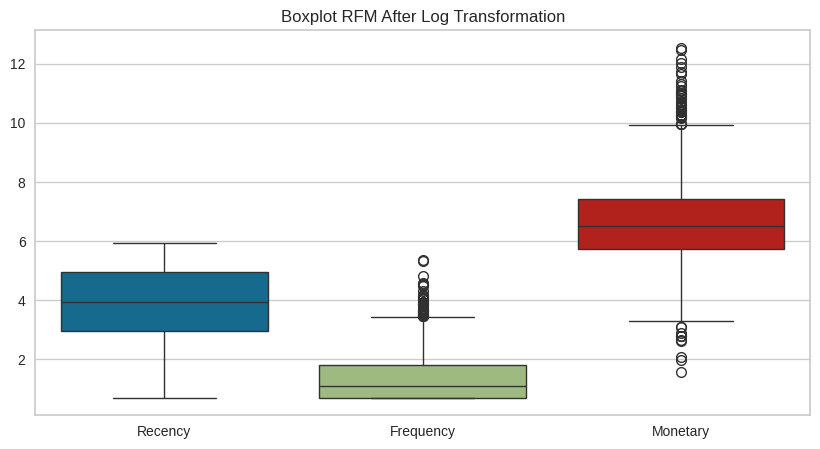

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Boxplot setelah log transform
plt.figure(figsize=(10,5))

sns.boxplot(data=rfm)

plt.title('Boxplot RFM After Log Transformation')
plt.show()

**Insight**

Pada tahap preprocessing data, dilakukan penanganan outlier menggunakan metode log transformation dengan fungsi `log1p()`. Metode ini dipilih karena data RFM, khususnya pada fitur Frequency dan Monetary, memiliki distribusi yang sangat tidak merata serta mengandung banyak nilai ekstrem. Kondisi tersebut umum terjadi pada dataset retail karena terdapat beberapa pelanggan dengan frekuensi transaksi dan total pembelian yang sangat tinggi dibanding pelanggan lainnya. Jika outlier tidak ditangani, maka proses clustering dapat menghasilkan centroid yang tidak optimal sehingga mempengaruhi kualitas pengelompokan data.

Penggunaan log transformation bertujuan untuk mengurangi pengaruh nilai ekstrem tanpa menghilangkan data penting. Berbeda dengan metode penghapusan outlier yang dapat menyebabkan hilangnya informasi pelanggan bernilai tinggi, log transformation tetap mempertahankan seluruh data namun mengubah distribusi data menjadi lebih stabil dan mendekati normal. Selain itu, metode ini juga membantu meningkatkan performa algoritma clustering seperti K-means Clustering karena perbedaan skala antar data menjadi lebih seimbang.

Fungsi `log1p()` digunakan karena lebih aman dalam menangani data yang memiliki nilai nol dibandingkan fungsi logaritma biasa. Dengan demikian, proses clustering dapat dilakukan dengan lebih optimal dan menghasilkan segmentasi pelanggan yang lebih representatif.


## Scaling

In [31]:
# Scaling RFM
# WAJIB sebelum clustering.

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

rfm_scaled = scaler.fit_transform(rfm)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=rfm.columns,
    index=rfm.index
)

rfm_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,0.973830,0.000000,0.882630
12347,0.077471,0.297874,0.619999
12348,0.695021,0.196884,0.540405
12349,0.439947,0.000000,0.538373
12350,0.964245,0.000000,0.387540


## Feature selection

In [32]:
from sklearn.decomposition import PCA

# copy data
scaled_df = rfm_scaled.copy()

# ambil data numerik
df_numerik = scaled_df.select_dtypes(include=['number']).columns

# Membuat objek PCA
pca = PCA(n_components=3)

# Terapkan PCA hanya pada data numerik
X_pca = pca.fit_transform(scaled_df[df_numerik])

# Menampilkan total variansi yang dijelaskan
total_variance = sum(pca.explained_variance_ratio_)
print(f"Total Variansi yang Dijelaskan oleh Komponen Utama: {total_variance}")

Total Variansi yang Dijelaskan oleh Komponen Utama: 0.9999999999999999


# **6. Modeling Kmeans**

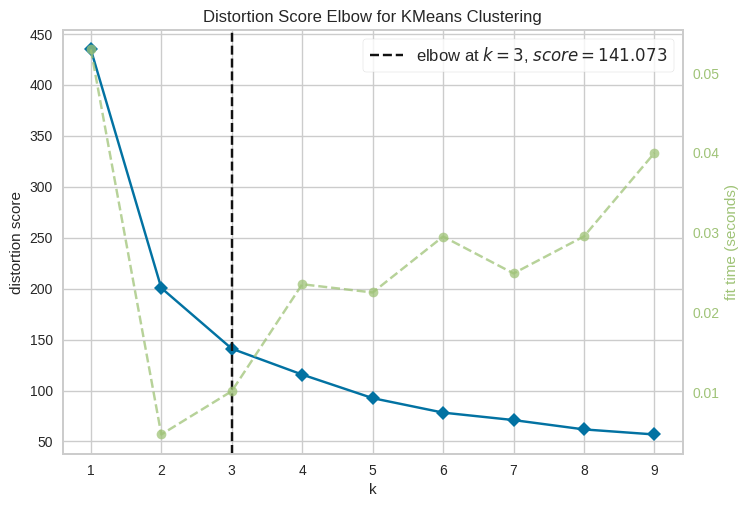

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [33]:
# Inisialisasi model KMeans tanpa parameter awal
kmeans = KMeans()

# Inisialisasi visualizer KElbow untuk menentukan jumlah cluster optimal
visualizer = KElbowVisualizer(kmeans, k=(1, 10))

# Fit visualizer dengan data untuk menemukan jumlah cluster optimal
visualizer.fit(X_pca)

# Menampilkan grafik elbow untuk analisis
visualizer.show()

In [34]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("Evaluasi Silhouette Score untuk beberapa k:")
for k in range(2,6):
    kmeans_test = KMeans(n_clusters=k, random_state=42)
    labels = kmeans_test.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    print(f"k={k}, silhouette={score:.4f}")

Evaluasi Silhouette Score untuk beberapa k:
k=2, silhouette=0.4486
k=3, silhouette=0.3699
k=4, silhouette=0.3668
k=5, silhouette=0.3595


In [35]:
# Training Versi tanpa PCA
from sklearn.cluster import KMeans

# KMeans tanpa PCA
kmeans = KMeans(
    n_clusters=2,
    init='k-means++',
    n_init=20,
    max_iter=600,
    random_state=42
)

clusters_kmens = kmeans.fit_predict(scaled_df)

# simpan hasil
scaled_df['cluster'] = clusters_kmens

In [36]:
# Evaluasi model tanpa PCA
from sklearn.metrics import silhouette_score

score = silhouette_score(scaled_df.drop(columns=['cluster']), clusters_kmens)
print("Silhouette Score:", score)

Silhouette Score: 0.44952521539643525


In [37]:
# training dengan PCA
from sklearn.cluster import KMeans

# Terapkan K-Means clustering
kmeans = KMeans(
    n_clusters=2,
    init='k-means++',
    n_init=20,
    max_iter=600,
    random_state=42
)

clusters_kmens = kmeans.fit_predict(X_pca)

# Menambahkan hasil clustering ke dataframe
scaled_df['cluster'] = clusters_kmens

In [38]:
# Evaluasi model dengan silhoutte scorr dengan PCA
from sklearn.metrics import silhouette_score

silhouette_avg = silhouette_score(X_pca, clusters_kmens)
print(f"Silhouette Score Kmens: {silhouette_avg:.4f}")

Silhouette Score Kmens: 0.4495


In [39]:
scaled_df.head()

,Recency,Frequency,Monetary,cluster
CustomerID,,,,
12346,0.973830,0.000000,0.882630,0
12347,0.077471,0.297874,0.619999,1
12348,0.695021,0.196884,0.540405,0
12349,0.439947,0.000000,0.538373,1
12350,0.964245,0.000000,0.387540,0


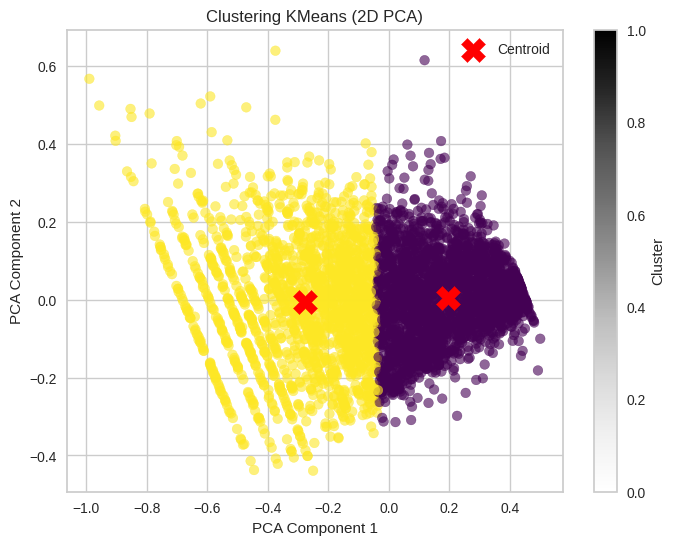

In [40]:
# Visualisasi 2D
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Plot data
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters_kmens,
    cmap='viridis',
    alpha=0.6
)

# Ambil centroid
centroids = kmeans.cluster_centers_

# Plot centroid
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    s=300,
    c='red',
    marker='X',
    label='Centroid'
)

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Clustering KMeans (2D PCA)')
plt.legend()
plt.colorbar(label='Cluster')
plt.show()

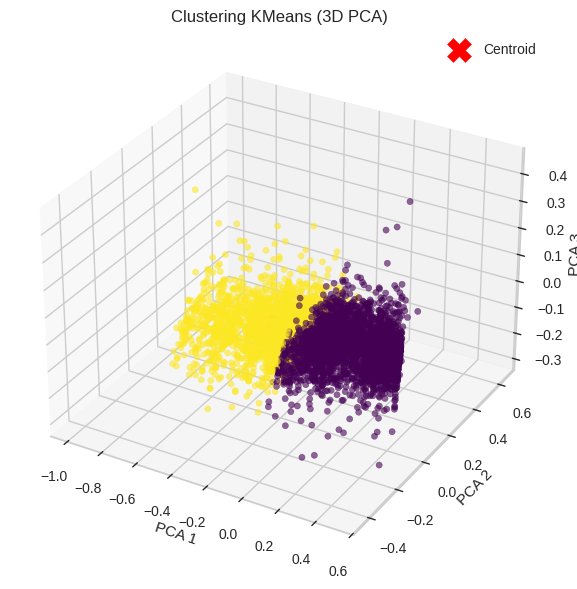

In [41]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

# Plot data
ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    X_pca[:, 2],
    c=clusters_kmens,
    cmap='viridis',
    alpha=0.6
)

# Ambil centroid
centroids = kmeans.cluster_centers_

# Plot centroid
ax.scatter(
    centroids[:, 0],
    centroids[:, 1],
    centroids[:, 2],
    s=300,
    c='red',
    marker='X',
    label='Centroid'
)

ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.set_zlabel('PCA 3')
ax.set_title('Clustering KMeans (3D PCA)')
ax.legend()

plt.show()

**Insight**

Berdasarkan hasil evaluasi menggunakan Silhouette Score, jumlah cluster terbaik diperoleh pada nilai k=2 dengan skor sebesar 0.4495. Hasil visualisasi PCA menunjukkan bahwa kedua cluster memiliki pemisahan yang cukup jelas dengan overlap yang relatif kecil. Hal ini mengindikasikan bahwa algoritma K-Means mampu mengelompokkan pelanggan berdasarkan pola perilaku transaksi dengan cukup baik. Cluster yang terbentuk dapat merepresentasikan dua kelompok utama pelanggan dengan karakteristik perilaku yang berbeda.

# **7. Mengeksport Data**

1. Simpan nama kolom hasil clustering dengan nama `Target`.
2. Simpan hasilnya ke dalam file CSV menggunakan function `to_csv()`.

In [75]:
# Tambahkan cluster ke RFM dulu
rfm_scaled['cluster'] = clusters_kmens

In [76]:
# Ambil hanya kolom cluster

cluster_data = rfm_scaled[['cluster']]

In [77]:
# Merge ke dataset asli
df_clean_prep = df_clean_prep.merge(
    cluster_data,
    left_on='CustomerID',
    right_index=True,
    how='left'
)

In [79]:
df_clean_prep.head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Month,cluster
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12,0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12,0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,0
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850,United Kingdom,15.30,2010-12,0
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850,United Kingdom,25.50,2010-12,0
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850,United Kingdom,11.10,2010-12,0
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850,United Kingdom,11.10,2010-12,0
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047,United Kingdom,54.08,2010-12,1


In [82]:
# simpan dataframe ke CSV
df_clean_prep.to_csv('Data_hasil_clustering_kmeans.csv', index=False)

print("File berhasil disimpan!")

File berhasil disimpan!


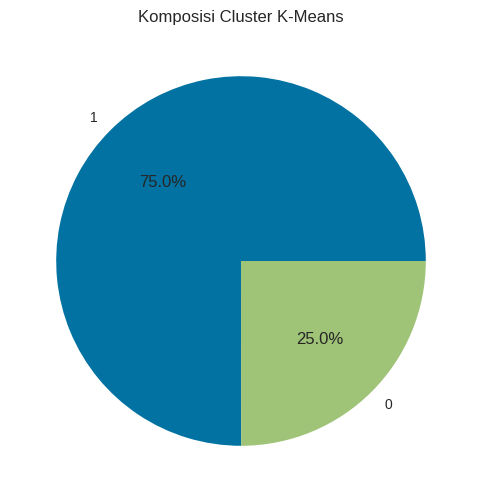

In [80]:
import matplotlib.pyplot as plt

# hitung jumlah data tiap cluster
cluster_counts = df_clean_prep['cluster'].value_counts()

# pie chart
plt.figure(figsize=(6,6))
plt.pie(
    cluster_counts,
    labels=cluster_counts.index,
    autopct='%1.1f%%'
)

plt.title('Komposisi Cluster K-Means')
plt.show()

In [81]:
# Pertama lihat dulu rata-rata RFM tiap cluster:

rfm_scaled.groupby('cluster').mean()

,Recency,Frequency,Monetary
cluster,,,
0,0.773638,0.065880,0.407968
1,0.354403,0.244766,0.528241


**Insight**

Hasil clustering menunjukkan bahwa pelanggan berhasil dikelompokkan menjadi dua segmen utama berdasarkan perilaku transaksi menggunakan metode RFM. Cluster pertama terdiri dari pelanggan dengan aktivitas transaksi rendah dan kontribusi pengeluaran yang kecil sehingga dikategorikan sebagai inactive customers. Sementara itu, cluster kedua terdiri dari pelanggan yang lebih aktif dan memiliki nilai transaksi lebih tinggi sehingga dikategorikan sebagai active customers. Segmentasi ini dapat membantu perusahaan dalam menentukan strategi pemasaran yang lebih tepat sasaran berdasarkan karakteristik masing-masing pelanggan.